## Упражнение 2.5 (стр.86)

In [2]:
import math
import numpy as np
import matplotlib.pyplot as plt

### Задание 1

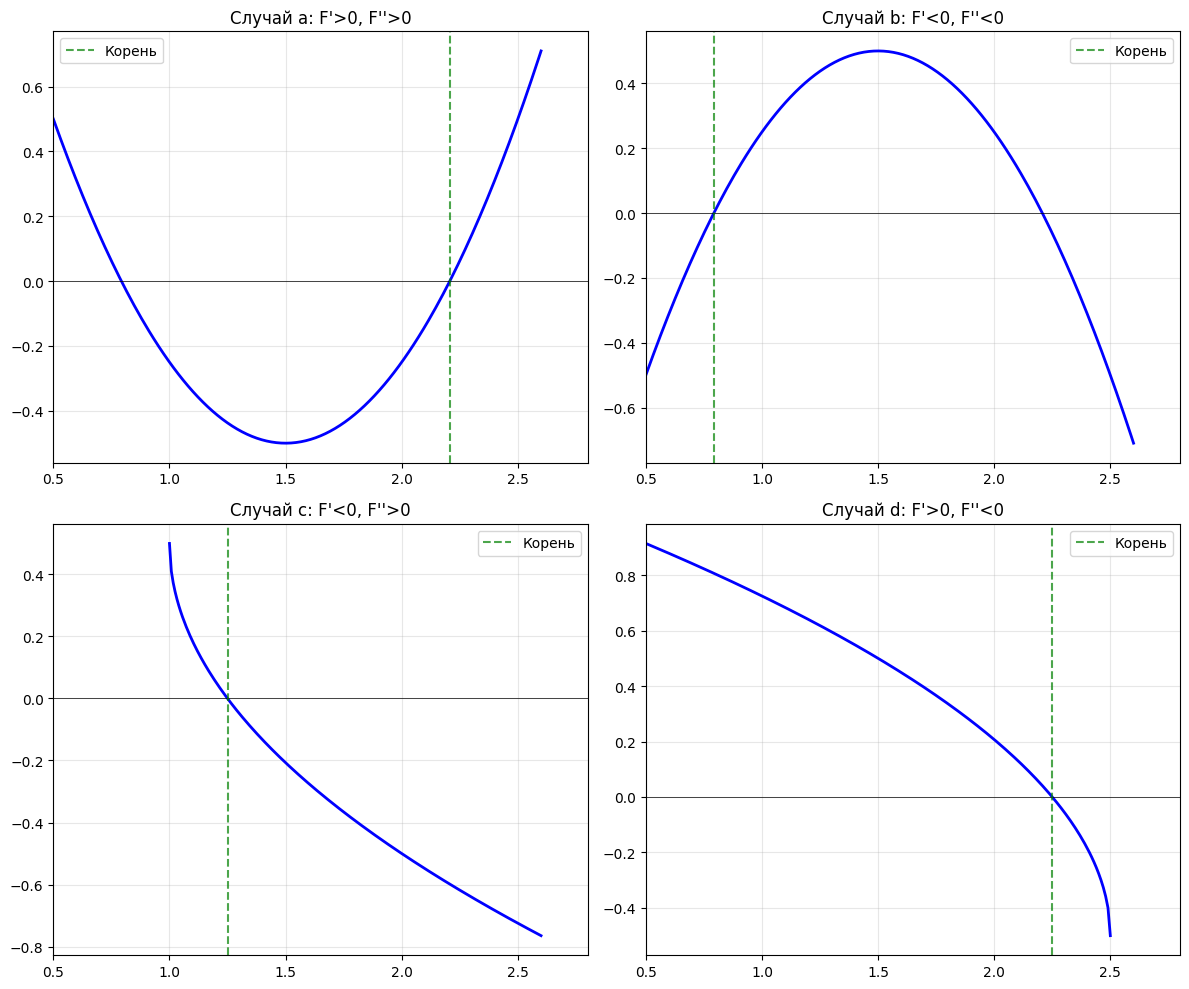

In [3]:
funcs = [
    lambda x: (x-1.5)**2 - 0.5,
    lambda x: -(x-1.5)**2 + 0.5,
    lambda x: -np.sqrt(x-1) + 0.5,
    lambda x: np.sqrt(2.5-x) - 0.5
]

titles = ["F'>0, F''>0", "F'<0, F''<0", "F'<0, F''>0", "F'>0, F''<0"]
roots = [1.5+np.sqrt(0.5), 1.5-np.sqrt(0.5), 1.25, 2.25]
x_ranges = [(0.5, 2.6), (0.5, 2.6), (1.0, 2.6), (0.5, 2.5)]

fig, axes = plt.subplots(2, 2, figsize=(12, 10))
axes = axes.flatten()

for i, (f, title, root, x_range) in enumerate(zip(funcs, titles, roots, x_ranges)):
    x = np.linspace(x_range[0], x_range[1], 200)
    y = f(x)

    axes[i].plot(x, y, 'b-', linewidth=2)
    axes[i].axhline(0, color='black', linewidth=0.5)
    axes[i].axvline(root, color='g', linestyle='--', alpha=0.7, label='Корень')
    axes[i].set_title(f'Случай {chr(97+i)}: {title}')
    axes[i].set_xlim(0.5, 2.8)
    axes[i].grid(True, alpha=0.3)
    axes[i].legend()

plt.tight_layout()
plt.show()

### Задание 2

In [ ]:
from tabulate import tabulate

def f(x):
    """Исходная функция: x³ + 3x² - 24x + 1"""
    return x**3 + 3*x**2 - 24*x + 1

def df(x):
    """Первая производная: 3x² + 6x - 24"""
    return 3*x**2 + 6*x - 24

def d2f(x):
    """Вторая производная: 6x + 6"""
    return 6*x + 6

# начальные границы отрезка, содержащего корень
a, b = 0, 1
tol = 1e-6 # точность вычислений
max_iter = 100  # макс число итераций

print("--- Комбинированный метод хорд и касательных ---")
print(f"Уравнение: x³ + 3x² - 24x + 1 = 0")
print(f"Отрезок: [{a}, {b}]")
print(f"Точность: {tol}\n")

table_data = [] # для хранения результатов итераций
iterations = [] # для хранения промежуточных значений

for i in range(max_iter):
    #метод хорд
    x_chord = a - f(a) * (b - a) / (f(b) - f(a))
    
    # выбор точки для метода касательных
    if f(a) * d2f(a) > 0:
        x_newton = a - f(a) / df(a)
    else:
        x_newton = b - f(b) / df(b)
    
    iterations.append((x_chord, x_newton))
    
    x_mid = (x_chord + x_newton) / 2
    diff = abs(x_newton - x_chord)
    
    table_data.append([i+1, f"{x_chord:.6f}", f"{x_newton:.6f}", f"{diff:.6f}", f"{f(x_mid):.2e}"])
    
    #проверка достижения точности
    if diff < tol:
        root = x_mid
        break
    
     #уточнение отрезка для след итерации
    if f(x_chord) * f(x_newton) < 0:
        a, b = x_chord, x_newton
    else:
        a, b = min(x_chord, x_newton), max(x_chord, x_newton)
else:
    root = (a + b) / 2

#вывод результатов в табличном виде
print(tabulate(table_data, headers=["Итер.", "Метод хорд", "Метод касат.", "|x_хорд - x_кас|", "f(x_ср)"], tablefmt="grid", numalign="center"))

print(f"\nПриближённое значение корня: {root:.8f}")
print(f"Значение функции в корне: {f(root):.2e}")

--- Комбинированный метод хорд и касательных ---
Уравнение: x³ + 3x² - 24x + 1 = 0
Отрезок: [0, 1]
Точность: 1e-06

+---------+--------------+----------------+--------------------+-----------+
|  Итер.  |  Метод хорд  |  Метод касат.  |  |x_хорд - x_кас|  |  f(x_ср)  |
+=========+==============+================+====================+===========+
|    1    |     0.05     |    0.041667    |      0.008333      |  -0.0936  |
+---------+--------------+----------------+--------------------+-----------+
|    2    |   0.041889   |    0.041889    |         0          | -2.75e-06 |
+---------+--------------+----------------+--------------------+-----------+

Приближённое значение корня: 0.04188918
Значение функции в корне: -2.75e-06
